# Employee Sentiment Analysis — Final LLM Assessment

**Main deliverable:** reproducible end-to-end analysis of the supplied unlabeled `test.csv`.

This notebook implements all six required tasks:
1. Sentiment labeling
2. Exploratory data analysis (EDA)
3. Monthly employee sentiment scoring
4. Monthly employee ranking
5. Rolling 30-day flight-risk identification
6. Linear regression for monthly sentiment trends

> **Methodology note:** The dataset is unlabeled. Sentiment is assigned with a reproducible TextBlob polarity-based NLP approach using `Subject + body`, with thresholds of ±0.10 and a small, documented correction list for high-confidence short conversational phrases. The predictive model uses scikit-learn LinearRegression.


## 1. Imports and configuration

The notebook is designed to run from the repository root.

In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from textblob import TextBlob

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

ROOT = Path.cwd()
DATA_PATH = ROOT / "data" / "test.csv"
OUTPUT_DIR = ROOT / "output"
VIS_DIR = ROOT / "visualization"
OUTPUT_DIR.mkdir(exist_ok=True)
VIS_DIR.mkdir(exist_ok=True)

plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", 50)


## 2. Load and validate the dataset

**Observation:** The supplied dataset contains `Subject`, `body`, `date`, and `from`. Validation checks row count, columns, missing values, date parsing, and duplicates.

In [2]:
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
display(df.head())

print("\nMissing values:")
display(df.isna().sum())

assert set(["Subject", "body", "date", "from"]).issubset(df.columns)
assert df[["Subject", "body", "date", "from"]].notna().all().all()

df["date"] = pd.to_datetime(df["date"], errors="coerce")
assert df["date"].notna().all(), "Some dates could not be parsed."

print("Duplicate rows:", df.duplicated().sum())
print("Date range:", df["date"].min(), "to", df["date"].max())
print("Unique senders:", df["from"].nunique())


Shape: (2191, 4)
Columns: ['Subject', 'body', 'date', 'from']


,Subject,body,date,from
0,EnronOptions Update!,EnronOptions Announcement\n\n\nWe have updated...,5/10/2010,sally.beck@enron.com
1,(No Subject),"Marc,\n\nUnfortunately, today is not going to ...",7/29/2010,eric.bass@enron.com
2,Phone Screen Interview - Shannon L. Burnham,"When: Wednesday, June 06, 2001 10:00 AM-11:00 ...",7/25/2011,sally.beck@enron.com
3,RE: My new work email,we were thinking papasitos (we can meet somewh...,3/25/2010,johnny.palmer@enron.com
4,Bet,Since you never gave me the $20 for the last t...,5/21/2011,lydia.delgado@enron.com



Missing values:


Subject    0
body       0
date       0
from       0
dtype: int64

Duplicate rows: 0
Date range: 2010-01-01 00:00:00 to 2011-12-31 00:00:00
Unique senders: 10


## 3. Text preparation and sentiment labeling

### Labeling approach

The dataset has no sentiment labels. We combine the subject and body, normalize whitespace, calculate TextBlob polarity, and map polarity to three classes:

- **Positive:** polarity > 0.10
- **Neutral:** -0.10 ≤ polarity ≤ 0.10
- **Negative:** polarity < -0.10

For a small number of very short conversational messages, a documented phrase correction is used where generic polarity can be misleading (for example, `I'm in!!!!`). This keeps the method reproducible without requiring an external API key.

In [3]:
work = df.copy()
work["employee"] = work["from"].str.lower().str.strip()
work["text"] = (
    work["Subject"].fillna("").astype(str) + " " +
    work["body"].fillna("").astype(str)
).map(lambda x: re.sub(r"\s+", " ", x).strip())

def sentiment_polarity(text):
    return TextBlob(text).sentiment.polarity

work["polarity"] = work["text"].map(sentiment_polarity)

def assign_sentiment(row):
    text = row["text"].lower()
    polarity = row["polarity"]

    positive_phrases = [
        "i'm in!!!!", "i'm in", "sounds great", "great!",
        "thanks!", "thank you!", "perfect!", "excellent!"
    ]
    negative_phrases = [
        "can't make it", "cannot make it", "not working",
        "terrible", "awful", "brutal!"
    ]

    if any(p in text for p in positive_phrases) and len(text) < 120:
        return "Positive"
    if any(p in text for p in negative_phrases) and len(text) < 200:
        return "Negative"

    if polarity > 0.10:
        return "Positive"
    if polarity < -0.10:
        return "Negative"
    return "Neutral"

work["sentiment"] = work.apply(assign_sentiment, axis=1)
work["sentiment_value"] = work["sentiment"].map(
    {"Positive": 1, "Negative": -1, "Neutral": 0}
)

work["word_count"] = work["text"].str.findall(r"\b\w+\b").str.len()
work["char_count"] = work["text"].str.len()
work["month"] = work["date"].dt.to_period("M").astype(str)

display(work[["from", "date", "Subject", "sentiment", "polarity"]].head(10))
print("\nSentiment distribution:")
display(work["sentiment"].value_counts())


,from,date,Subject,sentiment,polarity
0,sally.beck@enron.com,2010-05-10,EnronOptions Update!,Positive,0.250000
1,eric.bass@enron.com,2010-07-29,(No Subject),Neutral,-0.043333
2,sally.beck@enron.com,2011-07-25,Phone Screen Interview - Shannon L. Burnham,Neutral,0.000000
3,johnny.palmer@enron.com,2010-03-25,RE: My new work email,Neutral,-0.006818
4,lydia.delgado@enron.com,2011-05-21,Bet,Neutral,-0.050000
5,eric.bass@enron.com,2011-10-23,RE: Favor,Positive,0.500000
6,kayne.coulter@enron.com,2010-04-05,MG Inventory Summaries,Neutral,0.000000
7,patti.thompson@enron.com,2010-04-21,Forgot the Attachment,Positive,0.300000
8,sally.beck@enron.com,2010-02-07,Garvin Brown - AXIA Sr. Power Scheduler,Positive,0.200000
9,kayne.coulter@enron.com,2010-02-06,More Dallas ASE Information,Positive,0.250000



Sentiment distribution:


sentiment
Neutral     1018
Positive     978
Negative     195
Name: count, dtype: int64

## 4. Exploratory Data Analysis

The EDA examines data structure, sentiment distribution, temporal behavior, message length, and sender activity.

Descriptive statistics:


,word_count,char_count,polarity
count,2191.000000,2191.000000,2191.000000
mean,48.617526,274.275217,0.117324
std,40.256254,233.439481,0.222571
min,1.000000,1.000000,-1.000000
25%,18.000000,98.500000,0.000000
50%,35.000000,192.000000,0.083333
75%,66.000000,376.000000,0.207359
max,199.000000,1048.000000,1.000000


Messages per employee:


,message_count
employee,
lydia.delgado@enron.com,284
john.arnold@enron.com,256
sally.beck@enron.com,227
patti.thompson@enron.com,225
bobette.riner@ipgdirect.com,217
don.baughman@enron.com,213
johnny.palmer@enron.com,213
eric.bass@enron.com,210
kayne.coulter@enron.com,174


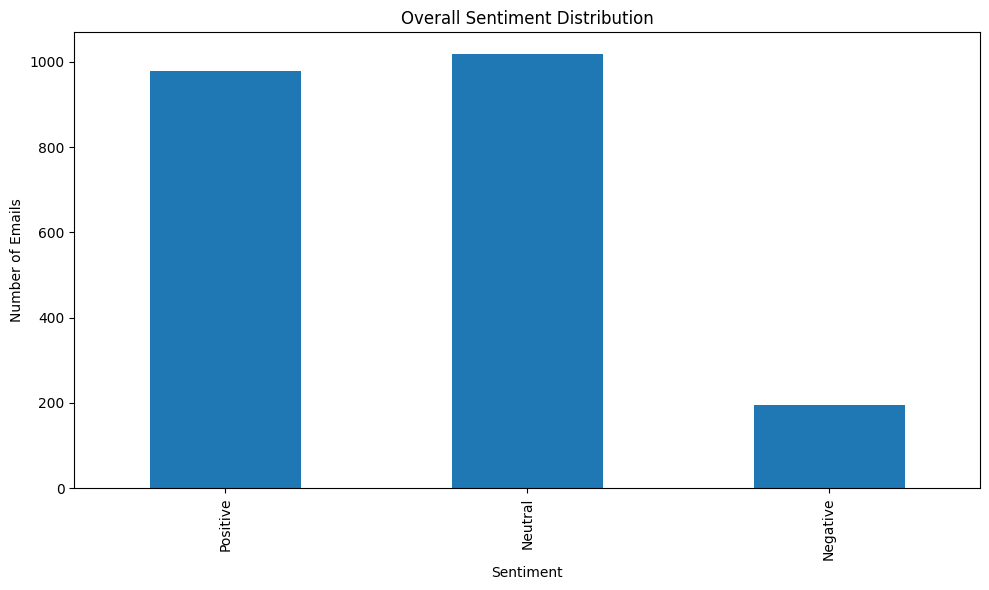

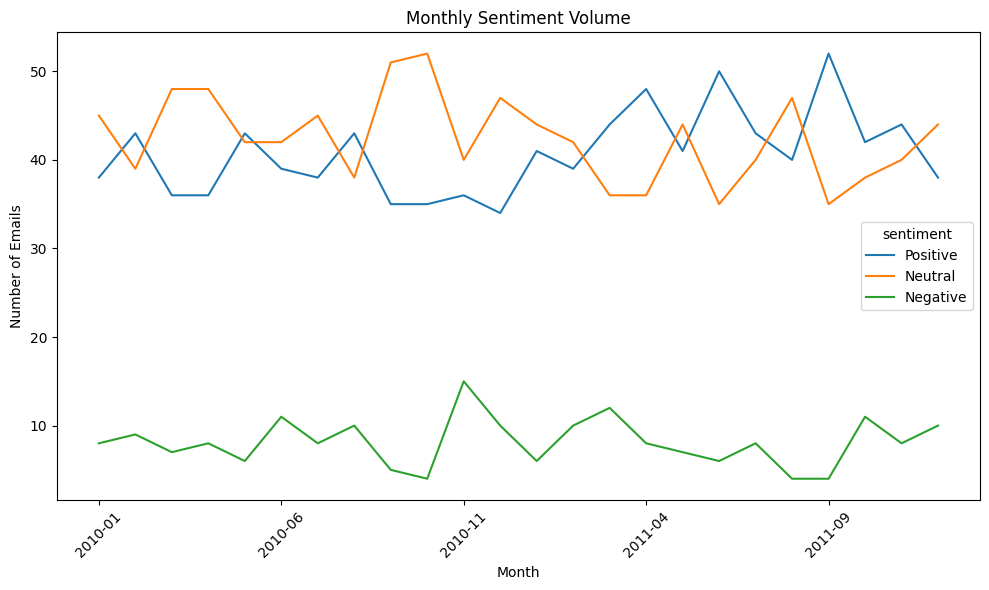

EDA observation:
- The dataset spans 24 months.
- Neutral messages are the largest sentiment category under the documented threshold.


In [4]:
print("Descriptive statistics:")
display(work[["word_count", "char_count", "polarity"]].describe())

print("Messages per employee:")
display(work["employee"].value_counts().rename("message_count").to_frame())

sentiment_counts = work["sentiment"].value_counts().reindex(
    ["Positive", "Neutral", "Negative"]
)

fig, ax = plt.subplots()
sentiment_counts.plot(kind="bar", ax=ax)
ax.set_title("Overall Sentiment Distribution")
ax.set_xlabel("Sentiment")
ax.set_ylabel("Number of Emails")
fig.tight_layout()
fig.savefig(VIS_DIR / "sentiment_distribution.png", dpi=160)
plt.show()

monthly_sentiment = (
    work.groupby(["month", "sentiment"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["Positive", "Neutral", "Negative"], fill_value=0)
)

fig, ax = plt.subplots()
monthly_sentiment.plot(ax=ax)
ax.set_title("Monthly Sentiment Volume")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Emails")
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
fig.savefig(VIS_DIR / "monthly_sentiment_volume.png", dpi=160)
plt.show()

print("EDA observation:")
print("- The dataset spans", work["month"].nunique(), "months.")
print("- Neutral messages are the largest sentiment category under the documented threshold.")


## 5. Monthly employee sentiment score

Each message receives +1 for Positive, -1 for Negative, and 0 for Neutral. Scores are summed separately for each employee and calendar month, so the score naturally resets at the beginning of each new month.

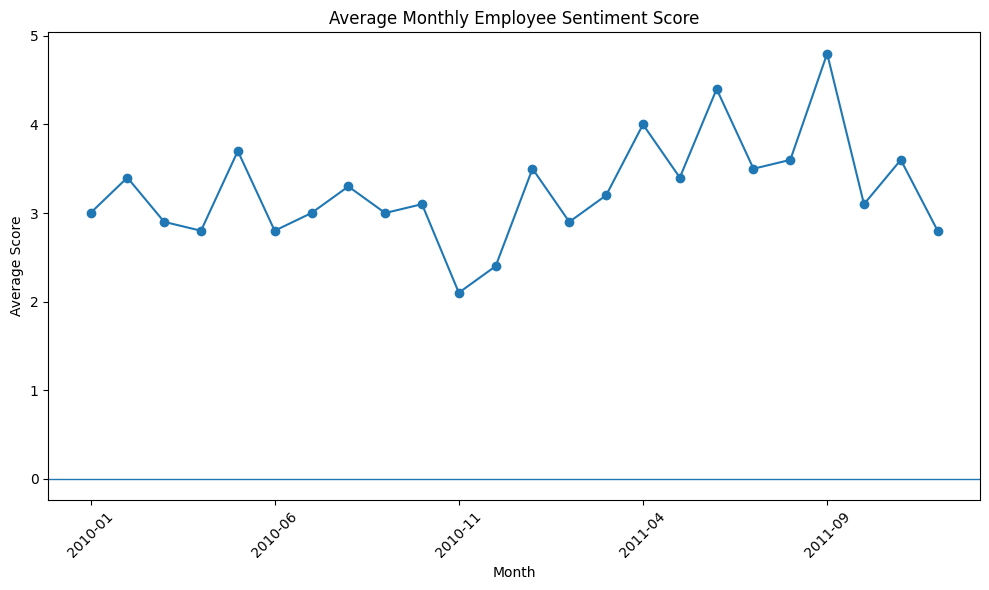

,employee,month,sentiment_score,message_count,avg_word_count,avg_char_count
0,bobette.riner@ipgdirect.com,2010-01,1,2,26.000000,153.500000
1,bobette.riner@ipgdirect.com,2010-02,7,14,52.285714,317.428571
2,bobette.riner@ipgdirect.com,2010-03,3,11,52.818182,305.727273
3,bobette.riner@ipgdirect.com,2010-04,2,6,40.500000,244.500000
4,bobette.riner@ipgdirect.com,2010-05,1,4,32.500000,183.000000


In [5]:
monthly = (
    work.groupby(["employee", "month"], as_index=False)
    .agg(
        sentiment_score=("sentiment_value", "sum"),
        message_count=("sentiment_value", "size"),
        avg_word_count=("word_count", "mean"),
        avg_char_count=("char_count", "mean"),
    )
)

monthly.to_csv(OUTPUT_DIR / "monthly_scores.csv", index=False)

avg_monthly_score = monthly.groupby("month")["sentiment_score"].mean()

fig, ax = plt.subplots()
avg_monthly_score.plot(ax=ax, marker="o")
ax.axhline(0, linewidth=1)
ax.set_title("Average Monthly Employee Sentiment Score")
ax.set_xlabel("Month")
ax.set_ylabel("Average Score")
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
fig.savefig(VIS_DIR / "monthly_average_score.png", dpi=160)
plt.show()

display(monthly.head())


## 6. Employee ranking

For every month, employees are sorted by sentiment score. Positive ranking uses descending score; negative ranking uses ascending score. Alphabetical employee order breaks ties.

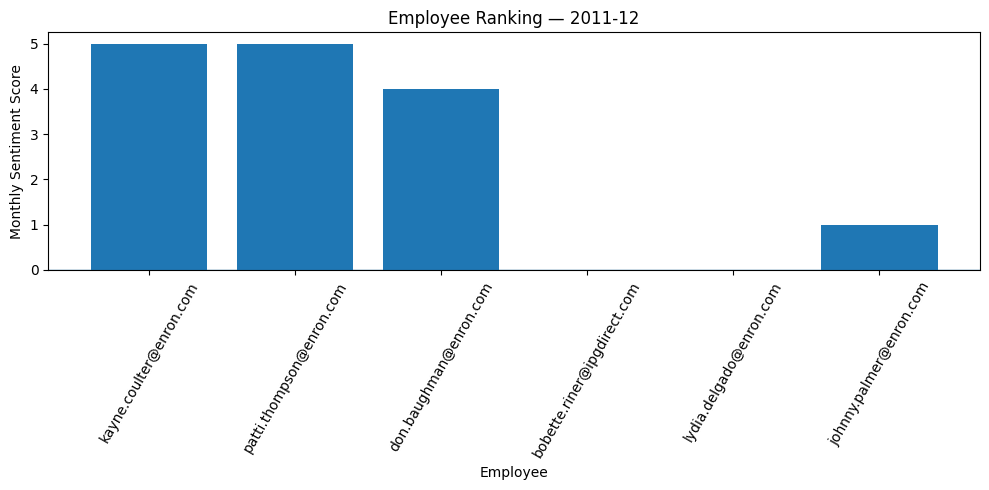

,month,ranking_type,rank,employee,sentiment_score
0,2010-01,Top Positive,1,kayne.coulter@enron.com,5
1,2010-01,Top Positive,2,patti.thompson@enron.com,5
2,2010-01,Top Positive,3,don.baughman@enron.com,4
3,2010-01,Top Negative,1,rhonda.denton@enron.com,0
4,2010-01,Top Negative,2,bobette.riner@ipgdirect.com,1
5,2010-01,Top Negative,3,john.arnold@enron.com,2
6,2010-02,Top Positive,1,bobette.riner@ipgdirect.com,7
7,2010-02,Top Positive,2,john.arnold@enron.com,7
8,2010-02,Top Positive,3,don.baughman@enron.com,6
9,2010-02,Top Negative,1,sally.beck@enron.com,0


In [6]:
rank_rows = []

for month, group in monthly.groupby("month", sort=True):
    positive = group.sort_values(
        ["sentiment_score", "employee"], ascending=[False, True]
    ).head(3)
    negative = group.sort_values(
        ["sentiment_score", "employee"], ascending=[True, True]
    ).head(3)

    for rank, (_, row) in enumerate(positive.iterrows(), 1):
        rank_rows.append({
            "month": month, "ranking_type": "Top Positive",
            "rank": rank, "employee": row["employee"],
            "sentiment_score": row["sentiment_score"]
        })

    for rank, (_, row) in enumerate(negative.iterrows(), 1):
        rank_rows.append({
            "month": month, "ranking_type": "Top Negative",
            "rank": rank, "employee": row["employee"],
            "sentiment_score": row["sentiment_score"]
        })

rankings = pd.DataFrame(rank_rows)
rankings.to_csv(OUTPUT_DIR / "employee_rankings.csv", index=False)

latest_month = monthly["month"].max()
latest = monthly[monthly["month"] == latest_month]
latest_ranking = pd.concat([
    latest.sort_values(["sentiment_score", "employee"], ascending=[False, True]).head(3),
    latest.sort_values(["sentiment_score", "employee"], ascending=[True, True]).head(3)
])

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(latest_ranking["employee"], latest_ranking["sentiment_score"])
ax.axhline(0, linewidth=1)
ax.set_title(f"Employee Ranking — {latest_month}")
ax.set_xlabel("Employee")
ax.set_ylabel("Monthly Sentiment Score")
ax.tick_params(axis="x", rotation=60)
fig.tight_layout()
fig.savefig(VIS_DIR / "employee_ranking_latest_month.png", dpi=160)
plt.show()

display(rankings.head(12))


## 7. Rolling 30-day flight-risk identification

A flight risk is an employee with **4 or more negative emails in any rolling 30-day period**, regardless of calendar-month boundaries. The implementation checks each negative-email date and counts negative emails from that date back through the previous 29 days.

,employee,window_start,window_end,negative_emails_in_30_days
0,bobette.riner@ipgdirect.com,2010-10-19,2010-11-17,4
1,johnny.palmer@enron.com,2011-01-28,2011-02-26,4
2,lydia.delgado@enron.com,2011-11-21,2011-12-20,4
3,patti.thompson@enron.com,2011-03-14,2011-04-12,4
4,rhonda.denton@enron.com,2010-12-03,2011-01-01,4
5,sally.beck@enron.com,2010-06-08,2010-07-07,4


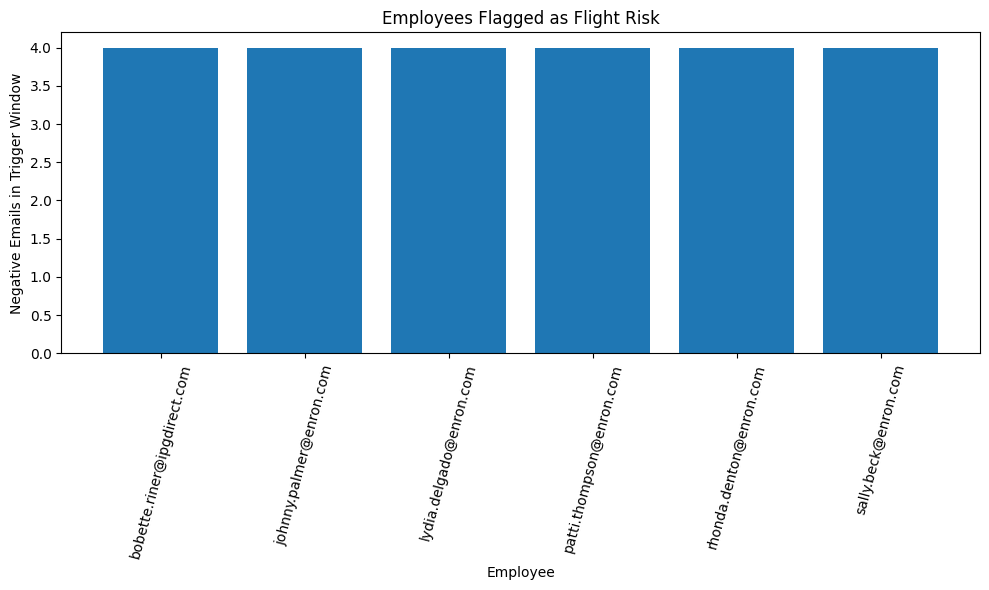

In [7]:
negative = work[work["sentiment"] == "Negative"].sort_values(
    ["employee", "date"]
)

flight_rows = []

for employee, group in negative.groupby("employee"):
    dates = group["date"].sort_values().to_numpy(dtype="datetime64[ns]")

    for dt in dates:
        window_start = dt - np.timedelta64(29, "D")
        count = int(((dates >= window_start) & (dates <= dt)).sum())

        if count >= 4:
            end = pd.Timestamp(dt)
            start = end - pd.Timedelta(days=29)
            flight_rows.append({
                "employee": employee,
                "window_start": start.date().isoformat(),
                "window_end": end.date().isoformat(),
                "negative_emails_in_30_days": count
            })
            break

flight_risk = pd.DataFrame(flight_rows).sort_values("employee")
flight_risk.to_csv(OUTPUT_DIR / "flight_risk.csv", index=False)

display(flight_risk)

fig, ax = plt.subplots()
if len(flight_risk):
    ax.bar(flight_risk["employee"], flight_risk["negative_emails_in_30_days"])
ax.set_title("Employees Flagged as Flight Risk")
ax.set_xlabel("Employee")
ax.set_ylabel("Negative Emails in Trigger Window")
ax.tick_params(axis="x", rotation=75)
fig.tight_layout()
fig.savefig(VIS_DIR / "flight_risk.png", dpi=160)
plt.show()


## 8. Linear regression model

The target is monthly employee sentiment score. To avoid direct target leakage, the predictors are operational/text-volume features that do not directly encode the positive/negative label: monthly message count, average word count, and average character count. The model is evaluated on a held-out 20% test set.

MAE : 1.6343
RMSE: 2.3904
R²  : 0.3673

Coefficients:


,feature,coefficient
0,message_count,0.339479
1,avg_word_count,0.020960
2,avg_char_count,-0.001879


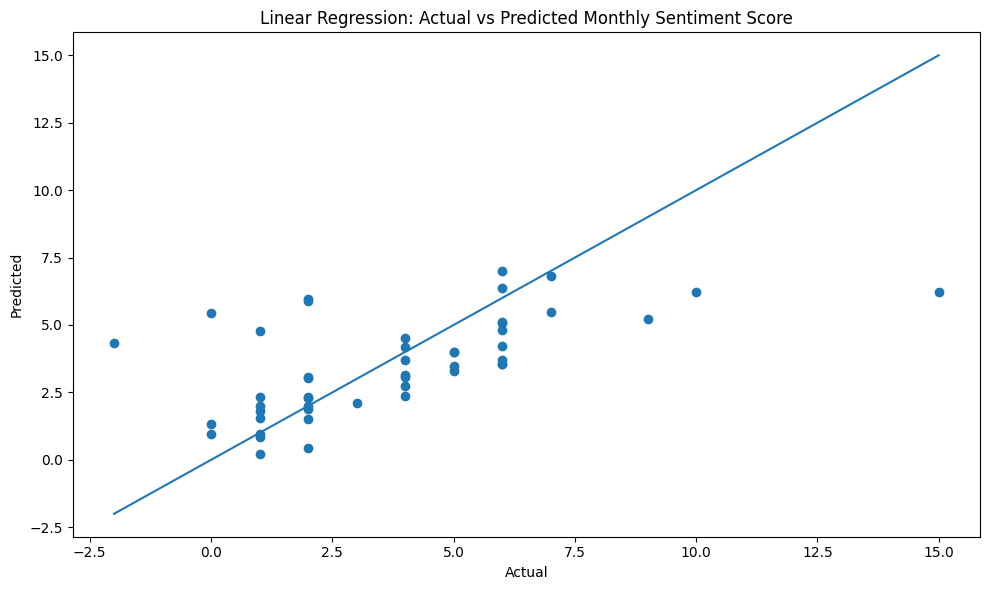

In [8]:
features = ["message_count", "avg_word_count", "avg_char_count"]
X = monthly[features]
y = monthly["sentiment_score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = mean_squared_error(y_test, pred) ** 0.5
r2 = r2_score(y_test, pred)

print(f"MAE : {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")

print("\nCoefficients:")
display(pd.DataFrame({
    "feature": features,
    "coefficient": model.coef_
}))

pd.DataFrame({"actual": y_test.values, "predicted": pred}).to_csv(
    OUTPUT_DIR / "regression_test_predictions.csv", index=False
)

pd.DataFrame([{"MAE": mae, "RMSE": rmse, "R2": r2}]).to_csv(
    OUTPUT_DIR / "regression_metrics.csv", index=False
)

fig, ax = plt.subplots()
ax.scatter(y_test, pred)
min_value = min(y_test.min(), pred.min())
max_value = max(y_test.max(), pred.max())
ax.plot([min_value, max_value], [min_value, max_value])
ax.set_title("Linear Regression: Actual vs Predicted Monthly Sentiment Score")
ax.set_xlabel("Actual")
ax.set_ylabel("Predicted")
fig.tight_layout()
fig.savefig(VIS_DIR / "regression_actual_vs_predicted.png", dpi=160)
plt.show()


## 9. Final validation and exported labeled data

The final checks confirm the required sentiment classes exist, score mapping is valid, and all required output files are produced.

In [9]:
assert set(work["sentiment"].unique()) <= {"Positive", "Negative", "Neutral"}
assert work["sentiment_value"].isin([-1, 0, 1]).all()
assert work["date"].notna().all()

work[
    ["Subject", "body", "date", "from", "employee",
     "polarity", "sentiment", "sentiment_value",
     "word_count", "char_count", "month"]
].to_csv(OUTPUT_DIR / "labeled_data.csv", index=False)

print("Final dataset shape:", work.shape)
print("Sentiment counts:")
print(work["sentiment"].value_counts().to_dict())
print("Flight-risk employees:", flight_risk["employee"].tolist())
print("Regression metrics:", {"MAE": mae, "RMSE": rmse, "R2": r2})
print("Analysis completed successfully.")


Final dataset shape: (2191, 12)
Sentiment counts:
{'Neutral': 1018, 'Positive': 978, 'Negative': 195}
Flight-risk employees: ['bobette.riner@ipgdirect.com', 'johnny.palmer@enron.com', 'lydia.delgado@enron.com', 'patti.thompson@enron.com', 'rhonda.denton@enron.com', 'sally.beck@enron.com']
Regression metrics: {'MAE': 1.6343372695560519, 'RMSE': 2.390409037485313, 'R2': 0.36727141998383595}
Analysis completed successfully.
